In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O


In [4]:
from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O


In [5]:
dff["CO2_CoCiP"] = dff["CO2"] + dff["CoCiP"]
dfo["CO2_CoCiP"] = dfo["CO2"] + dfo["CoCiP"]

dff["NOx_H2O"] = dff["NOx"] + dff["H2O"]
dfo["NOx_H2O"] = dfo["NOx"] + dfo["H2O"]

dff["Total"] = dff["CO2"] + dff["CoCiP"] + dff["NOx"] + dff["H2O"]
dfo["Total"] = dfo["CO2"] + dfo["CoCiP"] + dfo["NOx"] + dfo["H2O"]

In [6]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [7]:
my_diff[["NOx_diff", "H2O_diff", "NOx_H2O_diff"]]

,NOx_diff,H2O_diff,NOx_H2O_diff
0,5306.956917,82.717309,5389.674226
1,744.023697,-9.546170,734.477527
2,3937.045336,122.306983,4059.352319
3,4936.428602,-228.397754,4708.030847
4,44.734364,-38.663813,6.070551
...,...,...,...
4107,669.694824,13.594005,683.288829
4108,0.000000,0.000000,0.000000
4109,-79.820847,-38.887755,-118.708602
4110,-405.673900,-111.177532,-516.851432


In [ ]:
# Sect 4
fids = my_diff.query("CO2_CoCiP_diff < 0 and Total_diff > 0").flight_id.unique()
len(fids)

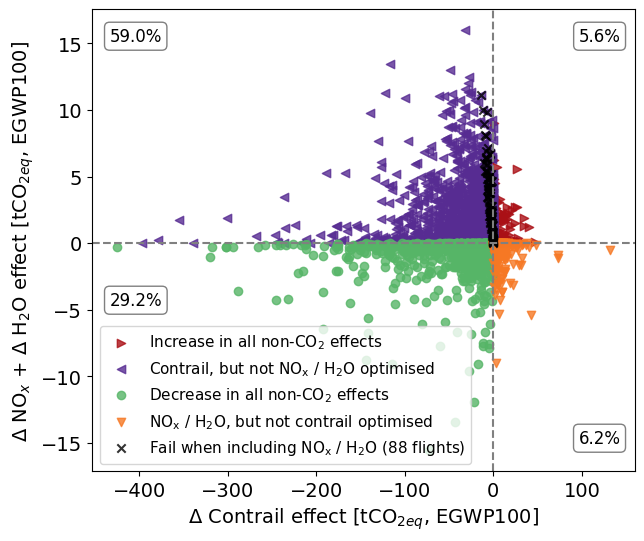

In [12]:
# categorize all of them
def _quadrant_label(x, y):
    if x >= 0 and y >= 0: return "Q1"
    if x < 0 and y >= 0: return "Q2"
    if x < 0 and y < 0: return "Q3"
    if x >= 0 and y < 0: return "Q4"


df = my_diff

quadrants = pd.DataFrame({
    "flight_id": df.flight_id,
    "day": df.day,
    "x": df["CoCiP_diff"] / 1e3,  # for tons
    "y": df["NOx_H2O_diff"] / 1e3  # for tons
})
quadrants["quadrant"] = [_quadrant_label(xi, yi) for xi, yi in zip(quadrants["x"], quadrants["y"])]

# Flag the 43 flights
flights_43 = my_diff.query("Total_diff > 0 and CO2_CoCiP_diff < 0").flight_id.unique()
quadrants["is_43"] = quadrants["flight_id"].isin(flights_43)
sub_scatters = quadrants.query("is_43 == True")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

my_colors = {
    "Q1": sns.color_palette("Reds")[5],
    "Q2": sns.color_palette("Purples")[5],
    "Q3": sns.color_palette("Greens")[3],
    "Q4": sns.color_palette("Oranges")[3]
}
friendly_name = {
    "Q1": r"Increase in all non-CO$_2$ effects",
    "Q2": r"Contrail, but not NO$\rm_x$ / H$_2$O optimised",
    "Q3": r"Decrease in all non-CO$_2$ effects",
    "Q4": r"NO$\rm_x$ / H$_2$O, but not contrail optimised",  #r"NO$\rm_x$ / H$_2$O penalty",
}
marker = {
    "Q1": ">",
    "Q2": "<",
    "Q3": "o",
    "Q4": "v",
}

q_size_rel = (quadrants.groupby("quadrant").size() / df.shape[0] * 100).to_dict()

for name, grp in quadrants.groupby("quadrant"):
    ax.scatter(grp["x"], grp["y"], color=my_colors[name], marker=marker[name], alpha=0.8,
               label=friendly_name[name])

ax.scatter(sub_scatters["x"], sub_scatters["y"], color="black", marker="x", alpha=0.8, label=r"Fail when including NO$\rm_x$ / H$_2$O" + f" ({len(fids)} flights)")

plt.axvline(0, color="gray", linestyle="--")
plt.axhline(0, color="gray", linestyle="--")

# Relative
plt.xlabel("$\Delta$ Contrail effect [tCO$_{2eq}$, EGWP100]", fontsize=14)
plt.ylabel("$\Delta$ NO$_x$ + $\Delta$ H$_2$O effect [tCO$_{2eq}$, EGWP100]", fontsize=14)
plt.tick_params(labelsize=14)
# ax.set_xlim([-100, 100])
# ax.set_ylim([-10, 20])

plt.legend(loc="lower left", fontsize=11)  # framealpha=1

# Top-right text
fig.text(
    0.88, 0.85, f"{q_size_rel['Q1']:.1f}%",
    ha="right", va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

# Top-left text
fig.text(
    0.15, 0.85, f"{q_size_rel['Q2']:.1f}%",
    ha="left", va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

# Bottom-left text
fig.text(
    0.15, 0.38, f"{q_size_rel['Q3']:.1f}%",
    ha="left", va="bottom",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

# Bottom-right text
fig.text(
    0.88, 0.15, f"{q_size_rel['Q4']:.1f}%",
    ha="right", va="bottom",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

plt.savefig("./figures/fig07.png", dpi=300, bbox_inches="tight")

In [9]:
print(my_diff.query("NOx_diff > 0").shape[0] / 4112, "as in rq1 and paper")
print(my_diff.query("NOx_diff >= 0").shape[0] / 4112, "as in quadrant plot")

0.6505350194552529 as in rq1 and paper
0.6750972762645915 as in quadrant plot
